In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


df = pd.read_csv('heart.csv')

#we have 303 rows and 14 columns
df.shape

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
#all columns
df.info()

#1 -> male , 0 -> female
#continuous variables : age , trestbps(resting blood pressure) , chol(cholesterol) , thalach(maximum heart rate) , oldpeak(ST depression induced by exercise relative to rest)

#categorical variables : sex , cp(type of chest pain) , fbs(fasting blood sugar) , restecg(resting electrocardiographic results) , 
#                   exang(exercise induced angina) , slope(slope of peak exercise ST) , ca (number of major vessels) , 
#                   thal(thalassemia) , target(predicted value)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
#no null values to handle
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

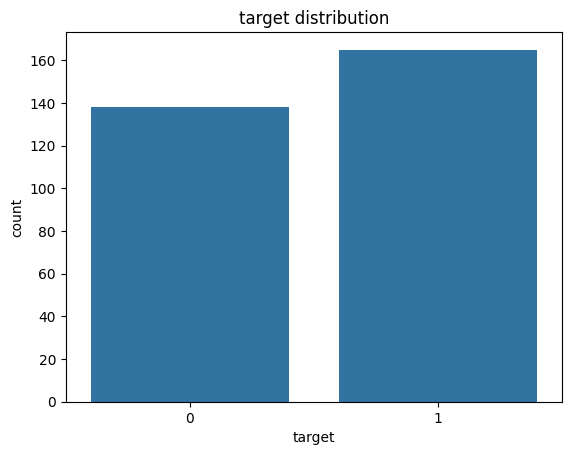

In [6]:
df['target'].value_counts()

sns.countplot(x='target' , data=df)
plt.title('target distribution')
plt.show()

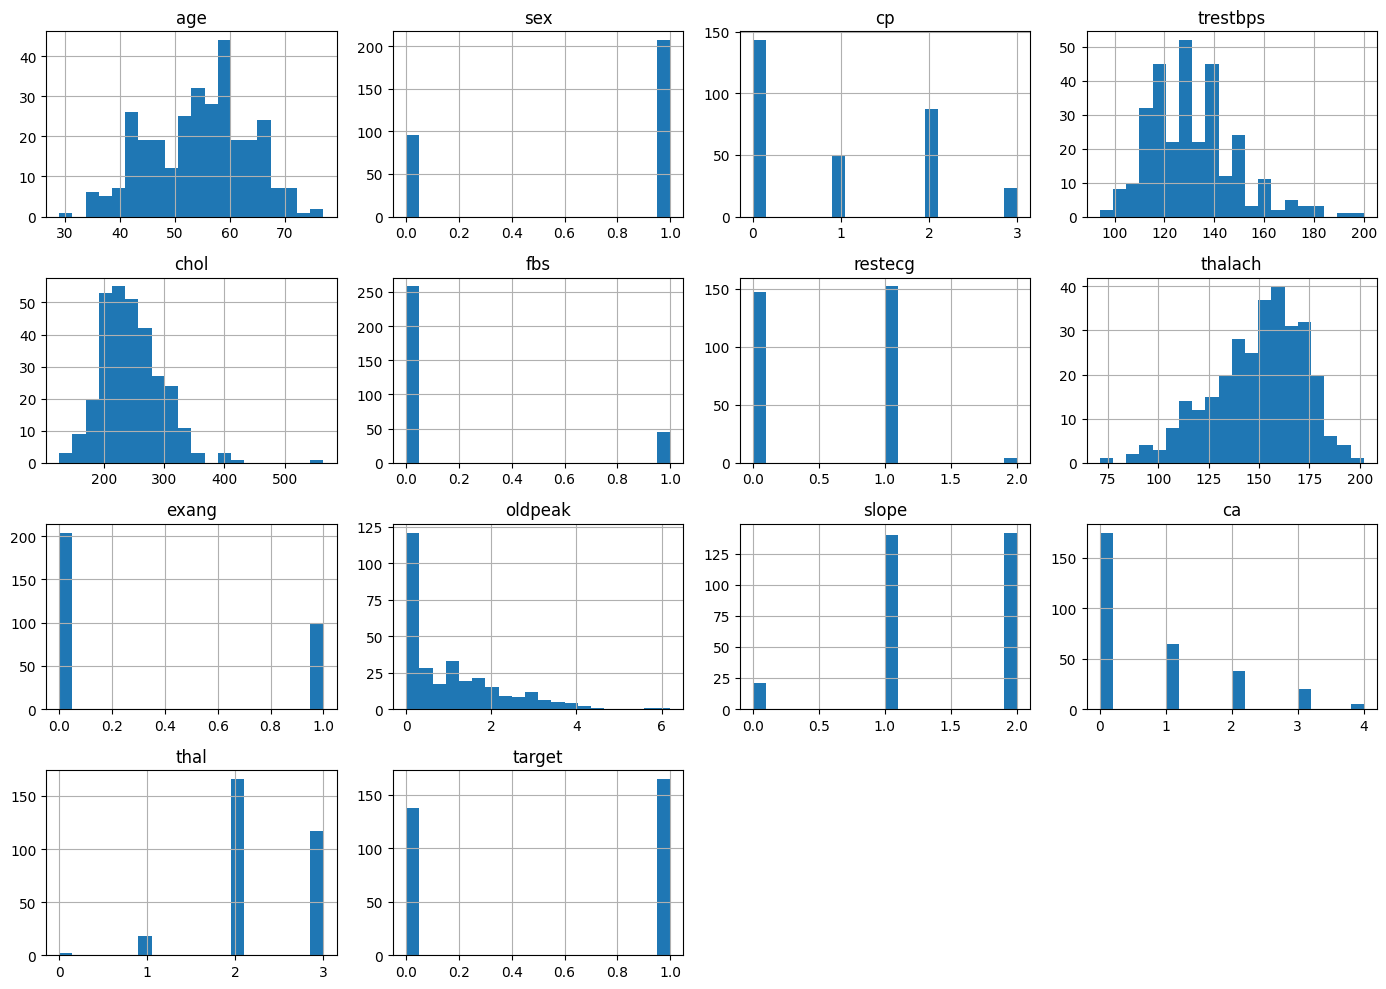

In [7]:
df.hist(figsize=(14 , 10) , bins=20)
plt.title('Feature Distributions')
plt.tight_layout()
plt.show()

#x axis -> actual value of that attribute
#y axis -> count

trestbps is mostly betweeen 100 to 160
cholestrol is mostly between 100 to 350
exang is either 0 or 1
oldpeak is left skewed
ca is mostly 0

outliers only for continuous features

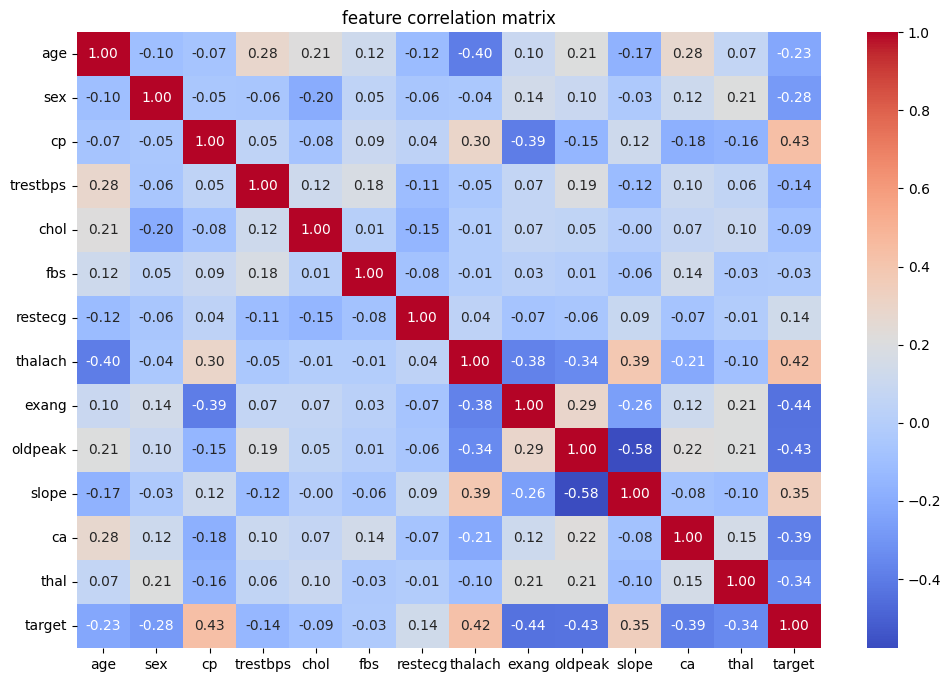

In [8]:
plt.figure(figsize=(12 , 8))
sns.heatmap(df.corr() , annot=True , fmt='.2f' , cmap='coolwarm')
plt.title('feature correlation matrix')
plt.show()

#df.corr() calculates correlation between every pair of columns in df
#annot(annotation) when True -> prints the number inside cell else only color
#fmt is for the format of numbers shown
#cmap is color map , coolwarm is just one of the color schemes

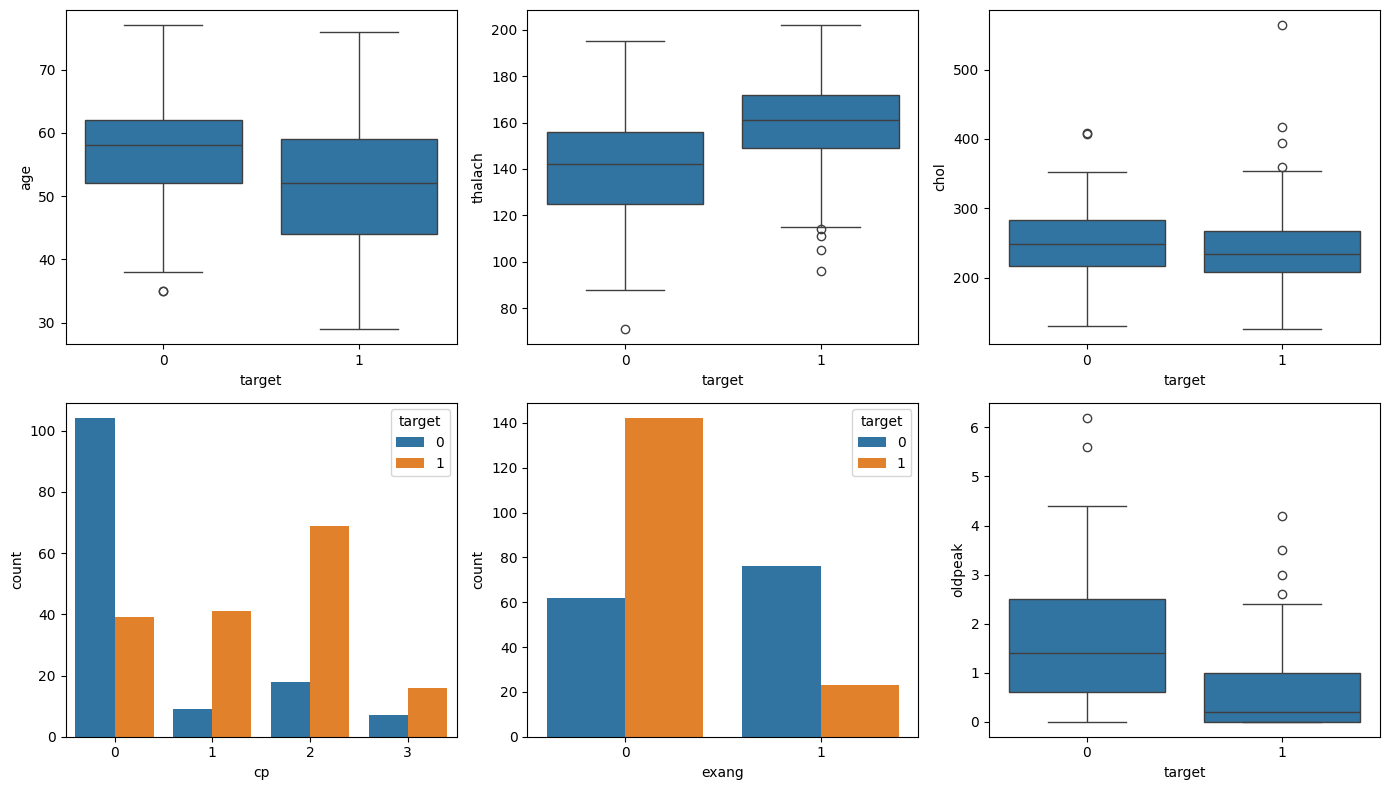

In [9]:
fig , axes = plt.subplots(2 , 3 , figsize=(14 , 8))

sns.boxplot(x='target' , y='age' , data=df , ax=axes[0,0])
sns.boxplot(x='target' , y='thalach' , data=df , ax=axes[0,1])
sns.boxplot(x='target', y='chol', data=df, ax=axes[0,2])
sns.countplot(x='cp', hue='target', data=df, ax=axes[1,0])
sns.countplot(x='exang', hue='target', data=df, ax=axes[1,1])
sns.boxplot(x='target', y='oldpeak', data=df, ax=axes[1,2])

plt.tight_layout()
plt.show()

In [10]:
#splitting features and target

y = df['target']
X = df.drop(['target'] , axis=1)

print(y.shape)
print(X.shape)

#continuous data needs scaling


#split data into test and trial in ratio of 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


print(y_train.shape)
print(y_test.shape)


(303,)
(303, 13)
(242, 13)
(61, 13)
(242,)
(61,)


In [11]:
#continuous data -> age , trestbps , chol , thalach , oldpeak
#normalising data -> (X - mean)/ (std dev)

numerical_cols = ["age", "trestbps", "chol", "thalach" , "oldpeak"]

scaler = StandardScaler()

#fit transform learns mean , std dev and then transforms
X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

#transform uses the already learnt mean and std dev
X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [12]:
#creating an instance
lr_model = LogisticRegression()

#model fits and learns from training data
lr_model.fit(X_train , y_train)

#model's prediction from test data inputs
y_pred = lr_model.predict(X_test)

#probabilies of output variable based on learning
y_proba = lr_model.predict_proba(X_test)

# print(y_pred)
# print(y_proba)

In [13]:
#out of all predictions , how many were correct
print(accuracy_score(y_test , y_pred))

#out of all the times we predicted true for heart disease , how many actually had it
print(precision_score(y_test , y_pred))

#out of all the people who had heart disease , for how many we predicted yes
print(recall_score(y_test , y_pred))

#somewhat balance of recall and precision 
print(f1_score(y_test , y_pred))

0.8032786885245902
0.7692307692307693
0.9090909090909091
0.8333333333333334


Text(0.5, 1.0, 'actual vs predicted values')

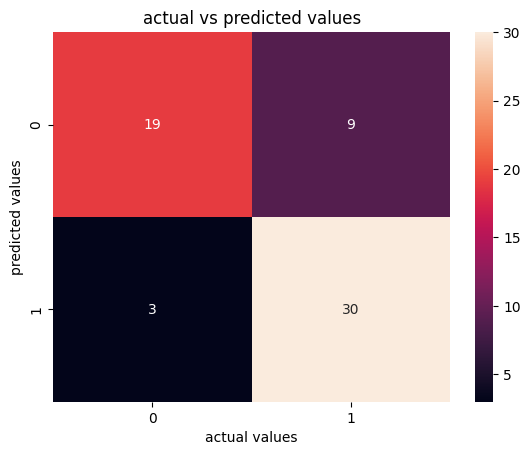

In [14]:
sns.heatmap(confusion_matrix(y_test , y_pred) , annot=True , fmt='d')
plt.xlabel('actual values')
plt.ylabel('predicted values')
plt.title('actual vs predicted values')

#(0, 0) -> true negative 
#(0, 1) -> false positive
#(1, 0) -> false negative
#(1, 1) -> true positive


our assumption is that is we output 1 is probability is > 0.5
our threshold is basically 0.5
ROC curve tests all thresholds from 0 to 1

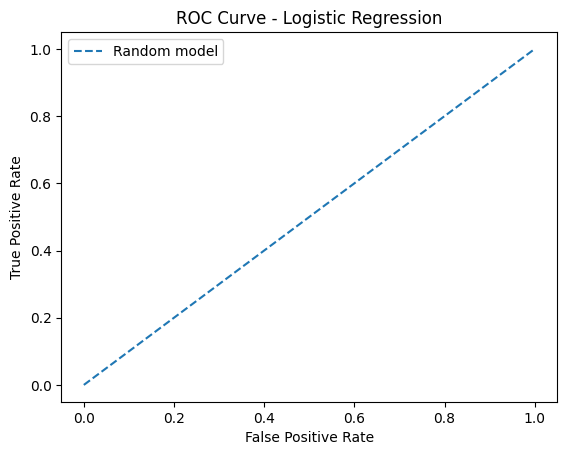

In [15]:
#fpr -> at each threshold , how many healthy people are wrongly flagged
#tpr -> at each threadhold , how many sick people are correctly flagged

fpr, tpr, thresholds = roc_curve(y_test, y_proba[:,1])
auc_score = roc_auc_score(y_test, y_proba[:,1])

#model with -- is some random model



plt.plot([0,1], [0,1], linestyle='--', label='Random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()


AUC score of 0.87 means that if I randomly pick one sick patient and one healthy patient from dataset , there is 87% change that model assigns a higher probability of heart disease to sick person than to healthy person

In our graph the threshold is decreasing from 1 to 0 from left to right

In [16]:
from sklearn.ensemble import RandomForestClassifier

#n_estimators -> number of trees in our random forest
#random_state is specified so that every time the code is run and data is shuffled , the
        #data is shuffled in the same way and gives the same result every time      
rf_model = RandomForestClassifier(
            n_estimators=100,
            random_state=42
    )
rf_model.fit(X_train , y_train)


rf_y_pred = rf_model.predict(X_test)

#probabilies of output variable based on learning
rf_y_proba = rf_model.predict_proba(X_test)

#out of all predictions , how many were correct
print(accuracy_score(y_test , rf_y_pred))

#out of all the times we predicted true for heart disease , how many actually had it
print(precision_score(y_test , rf_y_pred))

#out of all the people who had heart disease , for how many we predicted yes
print(recall_score(y_test , rf_y_pred))

#somewhat balance of recall and precision 
print(f1_score(y_test , rf_y_pred))

0.8360655737704918
0.7804878048780488
0.9696969696969697
0.8648648648648649


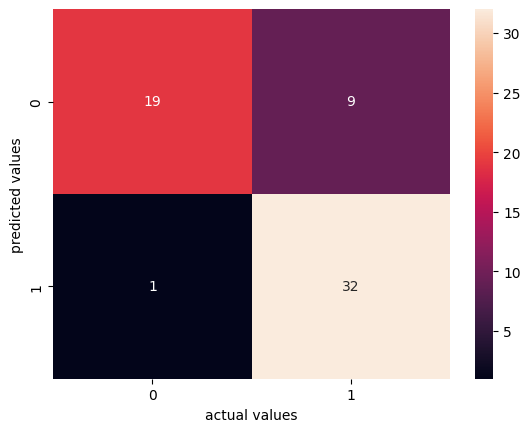

In [17]:
sns.heatmap(confusion_matrix(y_test , rf_y_pred) , annot=True , fmt='d')
plt.xlabel('actual values')
plt.ylabel('predicted values')
plt.show()

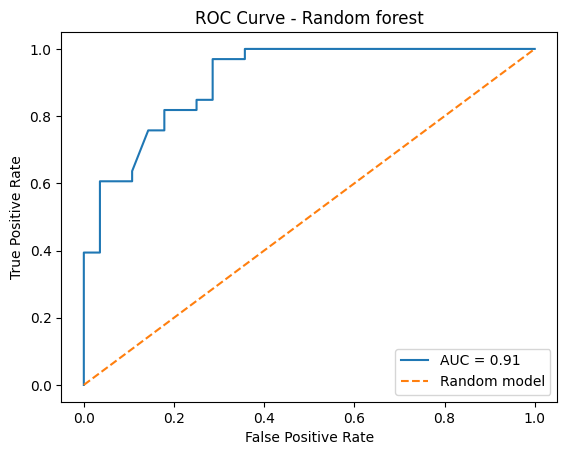

In [18]:
rf_fpr , rf_tpr , rf_thresholds = roc_curve(y_test , rf_y_proba[:,1])
rf_auc_score = roc_auc_score(y_test , rf_y_proba[:,1])

plt.plot(rf_fpr , rf_tpr , label=f'AUC = {rf_auc_score:.2f}')
plt.plot([0,1], [0,1], linestyle='--', label='Random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random forest')
plt.legend()
plt.show()


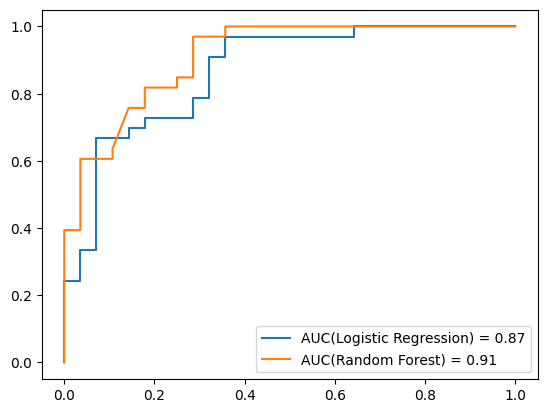

In [19]:
plt.plot(fpr, tpr , label=f'AUC(Logistic Regression) = {auc_score:.2f}')
plt.plot(rf_fpr , rf_tpr , label=f'AUC(Random Forest) = {rf_auc_score:.2f}')
plt.legend()
plt.show()


In [21]:
import joblib
joblib.dump(rf_model , r"C:\Users\Rajeev Kumar\Desktop\rano\vs code\heart_disease_predictor\model\rf_model.joblib")
joblib.dump(scaler , r"C:\Users\Rajeev Kumar\Desktop\rano\vs code\heart_disease_predictor\model\scalar.joblib")

loaded_model = joblib.load(r"C:\Users\Rajeev Kumar\Desktop\rano\vs code\heart_disease_predictor\model\rf_model.joblib")
loaded_scalar = joblib.load(r"C:\Users\Rajeev Kumar\Desktop\rano\vs code\heart_disease_predictor\model\scalar.joblib")


print(loaded_model.predict(X_test))

print(rf_y_pred)


[0 0 0 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0
 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1]
[0 0 0 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0
 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1]
